# Limitations on Quantum Information

In [17]:
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit, QuantumRegister

## Irrelevance of Global Phase
Given 2 state vectors $|\psi\rangle$ and $|\phi\rangle$ and a complex number $\alpha$ where $|\alpha| = 1$, $|\psi\rangle$ and $\phi\rangle$ *differ by a global phase* if:
$$|\psi\rangle = \alpha |\phi\rangle$$

2 state vectors that differ by a global phase represent the same physical state, which means that applying a global phase does not change the probability of any measurement outcome. This is because $|\alpha|$ must equal 1, so the statevector does not fundamentally change.

Note that in order for a phase to be considered global, the phase must apply to all entries of the state vector, for example $|-\rangle$ and $-|-\rangle$ differ by a global phase:

but $|-\rangle$ and $|+\rangle$ do not differ by a global phase, since the phase in the latter only applies to the first entry of the state vector.

In [6]:
plus = Statevector.from_label('+')
minus = Statevector.from_label('-')

# the Statevector.equiv() method checks if two state vectors differ up to a global phase
print(f"Are -|-⟩ and |-⟩ the same state? {minus.equiv(-1* minus)}")
if minus.equiv(-1* minus):
    print("The below are considered the same state:")
    display(minus.draw('latex', prefix='|-\\rangle = '))
    display((-1 * minus).draw('latex', prefix='-|-\\rangle = '))
print(f'Are |+⟩ and |-⟩ the same state? {plus.equiv(minus)}')

Are -|-⟩ and |-⟩ the same state? True
The below are considered the same state:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Are |+⟩ and |-⟩ the same state? False


## No-Cloning Theorem
It is impossible to create an identical copy of an arbitrary unknown quantum state.

Specifics can be found [here](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/quantum-circuits/limitations-on-quantum-information#no-cloning-theorem), but the intuition is that there cannot be two systems $X$ and $Y$ such that for any state $|\phi\rangle$ of $Y$, there is a unitary operation $U$ such that:
$$U(|\psi\rangle \otimes |\phi\rangle) = |\psi\rangle \otimes |\psi\rangle$$
Which means that you cannot initialize $Y$ to any state such that the above equation will produce a copy of $|\psi\rangle$.

There are 2 (kind of) caveats to the no-cloning theorem:
1. There are methods to approximately clone a quantum state, but absolute cloning on an arbitrary state is impossible.
2. There are certain states that can be cloned, for example the basis states $|0\rangle$ and $|1\rangle$ can be cloned using a CNOT gate:

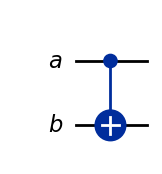

Final state after applying circuit to |00⟩:


<IPython.core.display.Latex object>

Final state after applying circuit to |10⟩:


<IPython.core.display.Latex object>

In [19]:
a = QuantumRegister(1, 'a')
b = QuantumRegister(1, 'b')

qc = QuantumCircuit(a, b)
qc.cx(control_qubit=a[0], target_qubit=b[0])
display(qc.draw('mpl'))

initial_state = Statevector.from_label('00')
final_state = initial_state.evolve(qc)
print("Final state after applying circuit to |00⟩:")
display(final_state.draw('latex'))

initial_state = Statevector.from_label('10')
final_state = initial_state.evolve(qc)
print("Final state after applying circuit to |10⟩:")
display(final_state.draw('latex'))


Additionally, it's worth to note that the no-cloning theorem is not unique to quantum information, you cannot clone arbritary unknown classical probabilistic information either. For example, if you have a biased coin with an unknown bias, there is no way to create another coin with the same bias without first learning the bias of the original coin.

## Non-orthogonal states cannot be perfectly discriminated
Given 2 quantum states $|\psi\rangle$ and $|\phi\rangle$, if $|\psi\rangle$ and $|\phi\rangle$ are not orthogonal (i.e. $\langle \psi | \phi \rangle \neq 0$), then there is no way to discriminate (or tell them apart) between them perfectly.